In [10]:
import ssl
import re
# Disable SSL verification - because it is annoying
ssl._create_default_https_context = ssl._create_unverified_context

In [11]:
from convokit import Corpus, download

awry_corpus = Corpus(filename=download("conversations-gone-awry-cmv-corpus")) #contains personal attacks
winning_corpus = Corpus(filename=download("winning-args-corpus"))

KeyboardInterrupt: 

In [ ]:
#convert the data into a dataframe
df_awry = awry_corpus.get_utterances_dataframe()
df_winning = winning_corpus.get_utterances_dataframe()

In [25]:
#Splitting the winning df based on the comments
df_success_winning = df_winning[df_winning['meta.success'] == 1]
df_failure_winning = df_winning[df_winning['meta.success'] == 0]
df_blank_winning = df_winning [df_winning['meta.success'].isnull()]


In [21]:
print(df_awry.columns)
print(df_winning.columns)

Index(['timestamp', 'text', 'speaker', 'reply_to', 'conversation_id',
       'meta.score', 'meta.top_level_comment', 'meta.retrieved_on',
       'meta.gilded', 'meta.gildings', 'meta.subreddit', 'meta.stickied',
       'meta.permalink', 'meta.author_flair_text', 'meta.parsed', 'vectors',
       'total_words', 'average_words_per_conversation'],
      dtype='object')
Index(['timestamp', 'text', 'speaker', 'reply_to', 'conversation_id',
       'meta.pair_ids', 'meta.success', 'meta.approved_by',
       'meta.author_flair_css_class', 'meta.author_flair_text',
       'meta.banned_by', 'meta.controversiality', 'meta.distinguished',
       'meta.downs', 'meta.edited', 'meta.gilded', 'meta.likes',
       'meta.mod_reports', 'meta.num_reports', 'meta.replies',
       'meta.report_reasons', 'meta.saved', 'meta.score', 'meta.score_hidden',
       'meta.subreddit', 'meta.subreddit_id', 'meta.ups', 'meta.user_reports',
       'vectors', 'total_words', 'average_words_per_conversation'],
      dtype=

In [ ]:
# Import the configuration file (if using the config.py method)
from conflict_features.config import OPENAI_API_KEY

In [18]:
def count_words(text):
    words = re.findall(r'\w+', text)
    return len(words)

def count(df):
    df['total_words'] = df['text'].apply(count_words)
    df['average_words_per_conversation'] = df.groupby('conversation_id')['total_words'].transform('mean')
    return df['average_words_per_conversation'].mean()

In [27]:
def get_speakers_with_success_1(group):
    success_speakers = group.loc[group['meta.success'] == 1, 'speaker'].unique()
    return success_speakers

#get the list of speakers who have been awarded a delta
speakers_per_conversation = df_winning.groupby('conversation_id').apply(get_speakers_with_success_1)

#remove speakers who do not have a delta
winning_condensed = df_winning[df_winning.apply(lambda row: row['speaker'] in speakers_per_conversation[row['conversation_id']], axis=1)]

In [42]:
random_conversation_ids = winning_condensed['conversation_id'].sample(5)
winning_condensed_tiny = winning_condensed[winning_condensed['conversation_id'].isin(random_conversation_ids)]

In [ ]:
# #use the GPT API to tag each sentence as conflict or not

# import openai

# openai.api_key = OPENAI_API_KEY

# def detect_conflict(input_text,question,engine):
#     # Define a prompt that instructs the model to provide information about conflict
#     prompt = f"{question}\n{input_text}\n\nResponse:"

#     # Generate text based on the prompt
#     response = openai.Completion.create(
#         engine=engine,  # You can choose an appropriate engine
#         prompt=prompt,
#         max_tokens=100,  # Adjust the max tokens as needed
#         temperature=0.7,  # Adjust the temperature for creativity
#         top_p=1.0,
#         frequency_penalty=0.0,
#         presence_penalty=0.0
#     )

#     # Get the generated text from the model's response
#     generated_text = response.choices[0].text

#     # Analyze the generated text for indications of conflict (you can define your own criteria)
#     if 'text contains conflict' in generated_text.strip():
#         return 1 #Conflict detected
#     else:
#         return 0 #No conflict detected



In [39]:
def get_stats(df,dataset):
    print(f"Statistics for {dataset}")
    print("-------------------------------------------------------")
    print(f"Number of conversations: {df['conversation_id'].nunique()}")
    print(f"Average Conversation Length (These are not utterances): {int(df.groupby('conversation_id').size().mean())}")
    print(f"Average Number of Speakers Per Conversation: {int(df.groupby('conversation_id')['speaker'].nunique().mean())}")
    print(f"Average Number of Words Per Conversation: {int(count(df))}")
    print(" ")
    print(" ")
    

In [43]:
winning_condensed_tiny.to_csv('condensed.csv')

In [45]:
#drop rows after the last delta
import pandas as pd
# Create a mask for rows where meta.success is 1
success_mask = winning_condensed['meta.success'] == 1

# Group the DataFrame by 'conversation_id'
grouped = winning_condensed.groupby('conversation_id')

# Define a function to create a mask for each group and use it to filter the rows
def filter_rows(group):
    last_success_index = group[success_mask].index.max()
    if pd.notna(last_success_index):
        mask = group.index <= last_success_index
    else:
        mask = group.index
    return group[mask]

# Apply the function to each group and concatenate the results
filtered_df = grouped.apply(filter_rows)

# Reset the index to obtain the final DataFrame
filtered_df = filtered_df.reset_index(drop=True)


/var/folders/8j/rzq1_zj938vgp1cqknfrmc0m0000gn/T/ipykernel_51185/4115343455.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  last_success_index = group[success_mask].index.max()


In [46]:
get_stats(filtered_df,"Filtered Winning")

Statistics for Filtered Winning
-------------------------------------------------------
Number of conversations: 3051
Average Conversation Length (These are not utterances): 13
Average Number of Speakers Per Conversation: 2
Average Number of Words Per Conversation: 114
 
 


In [40]:
get_stats(df_awry,"Awry")
get_stats(df_winning,"Winning")
get_stats(winning_condensed,"Condensed Winning")

Statistics for Awry
-------------------------------------------------------
Number of conversations: 6842
Average Conversation Length (These are not utterances): 6
Average Number of Speakers Per Conversation: 3
Average Number of Words Per Conversation: 103
 
 
Statistics for Winning
-------------------------------------------------------
Number of conversations: 3051
Average Conversation Length (These are not utterances): 96
Average Number of Speakers Per Conversation: 38
Average Number of Words Per Conversation: 98
 
 
Statistics for Condensed Winning
-------------------------------------------------------
Number of conversations: 3051
Average Conversation Length (These are not utterances): 20
Average Number of Speakers Per Conversation: 2
Average Number of Words Per Conversation: 118
 
 


/var/folders/8j/rzq1_zj938vgp1cqknfrmc0m0000gn/T/ipykernel_51185/4165594154.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['total_words'] = df['text'].apply(count_words)
/var/folders/8j/rzq1_zj938vgp1cqknfrmc0m0000gn/T/ipykernel_51185/4165594154.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['average_words_per_conversation'] = df.groupby('conversation_id')['total_words'].transform('mean')


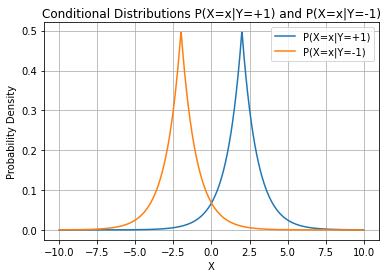

In [47]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 1000)
p_x_given_y_plus_1 = (1/2) * np.exp(-np.abs(x - 2))
p_x_given_y_minus_1 = (1/2) * np.exp(-np.abs(x + 2))

plt.plot(x, p_x_given_y_plus_1, label='P(X=x|Y=+1)')
plt.plot(x, p_x_given_y_minus_1, label='P(X=x|Y=-1)')
plt.xlabel('X')
plt.ylabel('Probability Density')
plt.legend()
plt.title('Conditional Distributions P(X=x|Y=+1) and P(X=x|Y=-1)')
plt.grid(True)
plt.show()
